<a href="https://colab.research.google.com/github/newazkhn/FloodPINN/blob/main/notebooks/08_improved_labels.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# 08_improved_labels.ipynb
# ============================================================
# PURPOSE  : Replace noisy SAR change detection labels with
#            higher quality ground truth from two sources:
#
#   Source 1 — Sen1Floods11 (Cloud to Street / CVPR 2020)
#              446 hand-labelled chips from 11 flood events
#              Already 512x512 at 10m — perfect match
#
#   Source 2 — UNOSAT Pakistan 2022 flood polygons
#              Human-verified GIS flood boundaries
#              Specific to your study area
#
# EXPECTED F1 IMPROVEMENT: 0.28 → 0.50-0.65
#
# AUTHOR   : Newaz Ibrahim Khan
# DATE     : April 2026
# ============================================================

!pip install earthengine-api geemap rasterio h5py -q
!pip install geopandas shapely -q

from google.colab import drive, auth
drive.mount('/content/drive')
auth.authenticate_user()

import ee
import geemap
import numpy as np
import rasterio
import os
import gc
import glob
import h5py
import geopandas as gpd
import requests
import zipfile
import shutil
import torch
from pathlib import Path

# Initialise GEE
ee.Initialize(project='ee-newazkhn')

# Paths
DRIVE_BASE     = '/content/drive/MyDrive'
OUTPUT_FOLDER  = f'{DRIVE_BASE}/FloodPINN_ImprovedData'
CHIPS_FOLDER   = f'{DRIVE_BASE}/FloodPINN_ImprovedChips'
PAKISTAN_FOLDER= f'{DRIVE_BASE}/FloodPINN_Pakistan'

os.makedirs(OUTPUT_FOLDER,  exist_ok=True)
os.makedirs(CHIPS_FOLDER,   exist_ok=True)
os.makedirs('/content/temp', exist_ok=True)

print("=" * 55)
print("  Notebook 08: Improved Labels Pipeline")
print("=" * 55)
print(f"\n  GEE project : ee-newazkhn")
print(f"\n  Output      : {OUTPUT_FOLDER}")
print(f"  Chips       : {CHIPS_FOLDER}")
print("\n✓ Setup complete")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 20.9 MB/s eta 0:00:00
Mounted at /content/drive
  Notebook 08: Improved Labels Pipeline

  GEE project : ee-newazkhn

  Output      : /content/drive/MyDrive/FloodPINN_ImprovedData
  Chips       : /content/drive/MyDrive/FloodPINN_ImprovedChips

✓ Setup complete


In [ ]:
# ============================================================
# Cell 2 — Export Sen1Floods11 hand-labelled chips via GEE
# ============================================================
# Sen1Floods11 is hosted on Google Cloud Storage
# We access it through GEE as a public asset
# Hand-labelled by human analysts at Cloud to Street
# Much higher quality than SAR change detection
# ============================================================

print("Accessing Sen1Floods11 via Google Earth Engine...")
print("This dataset has hand-labelled flood boundaries")
print("from 11 flood events across 6 continents.\n")

# Sen1Floods11 public GEE asset paths
# Hand labelled flood water chips
S1FLOODS_HAND_LABEL = (
    'projects/global-flood-db/'
    'assets/s1floods11/flood_events/'
    'hand_labeled/flood_label'
)

S1FLOODS_S1_DATA = (
    'projects/global-flood-db/'
    'assets/s1floods11/flood_events/'
    'hand_labeled/s1'
)

# Check if GEE assets are accessible
# If not, we use the GCS bucket directly
try:
    test = ee.ImageCollection(S1FLOODS_S1_DATA).size().getInfo()
    print(f"✓ GEE asset accessible: {test} images")
    USE_GEE_ASSET = True
except Exception as e:
    print(f"GEE asset not accessible: {e}")
    print("Will download directly from GCS bucket")
    USE_GEE_ASSET = False

print("\nSen1Floods11 dataset summary:")
print("  Hand-labelled chips : 446")
print("  Chip size           : 512 x 512 pixels")
print("  Resolution          : 10m")
print("  Flood events        : 11 (Bolivia, Cambodia,")
print("    Canada, DRC, Ghana, India,")
print("    Mekong, Nigeria, Paraguay,")
print("    Somalia, Sri Lanka)")
print("  Label classes       : 0=no water, 1=flood water")
print("  Label quality       : Human verified")

Accessing Sen1Floods11 via Google Earth Engine...
This dataset has hand-labelled flood boundaries
from 11 flood events across 6 continents.

GEE asset not accessible: ImageCollection.load: ImageCollection asset 'projects/global-flood-db/assets/s1floods11/flood_events/hand_labeled/s1' not found (does not exist or caller does not have access).
Will download directly from GCS bucket

Sen1Floods11 dataset summary:
  Hand-labelled chips : 446
  Chip size           : 512 x 512 pixels
  Resolution          : 10m
  Flood events        : 11 (Bolivia, Cambodia,
    Canada, DRC, Ghana, India,
    Mekong, Nigeria, Paraguay,
    Somalia, Sri Lanka)
  Label classes       : 0=no water, 1=flood water
  Label quality       : Human verified


In [ ]:
# ============================================================
# Cell 3 (Fixed v2) — Download with correct bucket path
# ============================================================

import subprocess
import os
import glob

S1F_DIR    = '/content/temp/sen1floods11'
S1F_HAND   = f'{S1F_DIR}/HandLabeled'
os.makedirs(S1F_HAND, exist_ok=True)

# First check what is inside HandLabeled
print("Checking HandLabeled folder structure...")
result = subprocess.run(
    ['gsutil', 'ls',
     'gs://sen1floods11/v1.1/data/flood_events/'
     'HandLabeled/'],
    capture_output=True, text=True)
print(result.stdout[:500])

# Download the full HandLabeled folder
print("\nDownloading HandLabeled folder...")
print("This may take 10-15 minutes...\n")

result = subprocess.run([
    'gsutil', '-m', 'cp', '-r',
    'gs://sen1floods11/v1.1/data/flood_events/'
    'HandLabeled/',
    S1F_HAND
], capture_output=True, text=True)

if result.returncode == 0:
    all_files = glob.glob(
        f'{S1F_HAND}/**/*', recursive=True)
    tif_files = [f for f in all_files
                 if f.endswith('.tif')]
    print(f"✓ Downloaded {len(tif_files)} files")
    print("\nSample filenames:")
    for f in tif_files[:10]:
        print(f"  {os.path.basename(f)}")
else:
    print(f"Error: {result.stderr[:300]}")
    # Try listing to understand structure
    print("\nListing subfolder contents...")
    result2 = subprocess.run(
        ['gsutil', 'ls', '-r',
         'gs://sen1floods11/v1.1/data/'
         'flood_events/HandLabeled/'],
        capture_output=True, text=True)
    print(result2.stdout[:1000])

Checking HandLabeled folder structure...
gs://sen1floods11/v1.1/data/flood_events/HandLabeled/JRCWaterHand/
gs://sen1floods11/v1.1/data/flood_events/HandLabeled/LabelHand/
gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S1Hand/
gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S1OtsuLabelHand/
gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S2Hand/


This may take 10-15 minutes...

✓ Downloaded 2230 files

Sample filenames:
  India_833266_S1OtsuLabelHand.tif
  USA_955053_S1OtsuLabelHand.tif
  Spain_2938657_S1OtsuLabelHand.tif
  Paraguay_403081_S1OtsuLabelHand.tif
  Sri-Lanka_956740_S1OtsuLabelHand.tif
  Somalia_649376_S1OtsuLabelHand.tif
  Sri-Lanka_377277_S1OtsuLabelHand.tif
  Bolivia_379434_S1OtsuLabelHand.tif
  Ghana_1078550_S1OtsuLabelHand.tif
  Paraguay_252217_S1OtsuLabelHand.tif


In [ ]:
# ============================================================
# Diagnostic — Check what actually downloaded
# ============================================================

import os
import glob

S1F_S1     = '/content/temp/sen1floods11/S1Hand'
S1F_LABELS = '/content/temp/sen1floods11/LabelHand'

print("Files in S1Hand folder:")
s1_files = glob.glob(f'{S1F_S1}/**/*', recursive=True)
if s1_files:
    for f in s1_files[:10]:
        print(f"  {f}")
    print(f"  ... total: {len(s1_files)} files")
else:
    print("  EMPTY — download failed")

print("\nFiles in LabelHand folder:")
lbl_files = glob.glob(f'{S1F_LABELS}/**/*',
                      recursive=True)
if lbl_files:
    for f in lbl_files[:10]:
        print(f"  {f}")
    print(f"  ... total: {len(lbl_files)} files")
else:
    print("  EMPTY — download failed")

print("\nAll files under /content/temp:")
all_files = glob.glob(
    '/content/temp/**/*', recursive=True)
for f in all_files[:20]:
    print(f"  {f}")

Files in S1Hand folder:
  EMPTY — download failed

Files in LabelHand folder:
  EMPTY — download failed

All files under /content/temp:
  /content/temp/sen1floods11
  /content/temp/sen1floods11/S1Hand
  /content/temp/sen1floods11/LabelHand


In [ ]:
# ============================================================
# Cell 4 Recovery — Recreate s1f_X_chips from disk
# ============================================================

import rasterio
import numpy as np
import glob
import os
from PIL import Image

BASE = '/content/temp/sen1floods11/HandLabeled/HandLabeled'

# Check files still exist
s1_files  = sorted(glob.glob(f'{BASE}/S1Hand/*.tif'))
lbl_files = sorted(glob.glob(f'{BASE}/LabelHand/*.tif'))

print(f"SAR files   : {len(s1_files)}")
print(f"Label files : {len(lbl_files)}")

if len(s1_files) == 0:
    print("\n⚠ Files gone — session reset cleared /content")
    print("Re-downloading Sen1Floods11...")

    import subprocess
    os.makedirs(f'{BASE}/S1Hand',    exist_ok=True)
    os.makedirs(f'{BASE}/LabelHand', exist_ok=True)

    subprocess.run([
        'gsutil', '-m', 'cp', '-r',
        'gs://sen1floods11/v1.1/data/flood_events/'
        'HandLabeled/',
        '/content/temp/sen1floods11/HandLabeled'
    ], capture_output=True)

    s1_files  = sorted(glob.glob(
        f'{BASE}/S1Hand/*.tif'))
    lbl_files = sorted(glob.glob(
        f'{BASE}/LabelHand/*.tif'))
    print(f"Re-downloaded: {len(s1_files)} SAR, "
          f"{len(lbl_files)} labels")

# Build lookup
s1_dict  = {
    os.path.basename(f).replace(
        '_S1Hand.tif', ''): f
    for f in s1_files}
lbl_dict = {
    os.path.basename(f).replace(
        '_LabelHand.tif', ''): f
    for f in lbl_files}

matched = set(s1_dict.keys()) & set(lbl_dict.keys())
print(f"Matched pairs: {len(matched)}")

def process_chip(s1_path, label_path, chip_size=512):
    try:
        with rasterio.open(s1_path) as src:
            s1_data = src.read().astype(np.float32)
            h, w    = src.height, src.width
        with rasterio.open(label_path) as src:
            label = src.read(1)
    except:
        return None, None, False

    if np.isfinite(s1_data).mean() < 0.7:
        return None, None, False

    label_binary = np.where(
        label == 1, 1, 0).astype(np.uint8)

    if (label >= 0).mean() < 0.5:
        return None, None, False

    if (label_binary == 1).mean() < 0.005:
        return None, None, False

    if h != chip_size or w != chip_size:
        s1_resized = np.zeros(
            (s1_data.shape[0], chip_size, chip_size),
            dtype=np.float32)
        for i in range(s1_data.shape[0]):
            band = np.nan_to_num(s1_data[i], nan=0.0)
            img  = Image.fromarray(band)
            s1_resized[i] = np.array(
                img.resize((chip_size, chip_size),
                           Image.BILINEAR),
                dtype=np.float32)
        s1_data = s1_resized

        lbl_img      = Image.fromarray(label_binary)
        label_binary = np.array(
            lbl_img.resize(
                (chip_size, chip_size),
                Image.NEAREST),
            dtype=np.uint8)

    vv = np.nan_to_num(s1_data[0], nan=0.0)
    vh = np.nan_to_num(
        s1_data[1] if s1_data.shape[0] > 1
        else s1_data[0], nan=0.0)

    X = np.zeros((8, chip_size, chip_size),
                 dtype=np.float32)
    X[0] = vv
    X[1] = vh
    X[2] = vv
    X[3] = vh

    return X, label_binary, True

# Process all chips
print(f"\nProcessing {len(matched)} chips...")
s1f_X_chips = []
s1f_y_chips = []
skipped = 0

for i, name in enumerate(sorted(matched)):
    if name not in s1_dict or \
       name not in lbl_dict:
        continue
    X, y, valid = process_chip(
        s1_dict[name], lbl_dict[name])
    if not valid:
        skipped += 1
        continue
    s1f_X_chips.append(X)
    s1f_y_chips.append(y)

    if (i+1) % 100 == 0:
        print(f"  {i+1}/{len(matched)} — "
              f"kept {len(s1f_X_chips)}")

print(f"\n✓ Done: {len(s1f_X_chips)} chips ready")
print(f"  Skipped: {skipped}")

SAR files   : 446
Label files : 446
Matched pairs: 446

Processing 446 chips...
  200/446 — kept 132
  300/446 — kept 190
  400/446 — kept 267

✓ Done: 310 chips ready
  Skipped: 136


In [ ]:
import glob
import os

# Find all tif files anywhere under the download folder
all_tifs = glob.glob(
    '/content/temp/sen1floods11/**/*.tif',
    recursive=True)

print(f"Total TIF files found: {len(all_tifs)}")
print("\nFirst 15 file paths:")
for f in all_tifs[:15]:
    print(f"  {f}")

Total TIF files found: 2230

First 15 file paths:
  /content/temp/sen1floods11/HandLabeled/HandLabeled/S1OtsuLabelHand/India_833266_S1OtsuLabelHand.tif
  /content/temp/sen1floods11/HandLabeled/HandLabeled/S1OtsuLabelHand/USA_955053_S1OtsuLabelHand.tif
  /content/temp/sen1floods11/HandLabeled/HandLabeled/S1OtsuLabelHand/Spain_2938657_S1OtsuLabelHand.tif
  /content/temp/sen1floods11/HandLabeled/HandLabeled/S1OtsuLabelHand/Paraguay_403081_S1OtsuLabelHand.tif
  /content/temp/sen1floods11/HandLabeled/HandLabeled/S1OtsuLabelHand/Sri-Lanka_956740_S1OtsuLabelHand.tif
  /content/temp/sen1floods11/HandLabeled/HandLabeled/S1OtsuLabelHand/Somalia_649376_S1OtsuLabelHand.tif
  /content/temp/sen1floods11/HandLabeled/HandLabeled/S1OtsuLabelHand/Sri-Lanka_377277_S1OtsuLabelHand.tif
  /content/temp/sen1floods11/HandLabeled/HandLabeled/S1OtsuLabelHand/Bolivia_379434_S1OtsuLabelHand.tif
  /content/temp/sen1floods11/HandLabeled/HandLabeled/S1OtsuLabelHand/Ghana_1078550_S1OtsuLabelHand.tif
  /content/temp/s

In [ ]:
# ============================================================
# Cell 8 (RAM-Safe) — Stream directly to HDF5
# ============================================================
# Never loads full dataset into RAM
# Writes Pakistan chips + Sen1Floods11 directly
# to HDF5 one batch at a time
# Max RAM usage: ~1GB at any point
# ============================================================

import h5py
import numpy as np
import os
import gc

CHIPS_OUT  = (
    '/content/drive/MyDrive/FloodPINN_ImprovedChips')
PAK_FOLDER = (
    '/content/drive/MyDrive/FloodPINN_Chips')
os.makedirs(CHIPS_OUT, exist_ok=True)

CHIP_SIZE = 512
N_BANDS   = 8

# ── Step 1: Count all chips without loading ──────────────
print("Step 1: Counting chips...")

# Count Pakistan chips
pak_counts = {}
for split in ['train', 'val', 'test']:
    path = f'{PAK_FOLDER}/floodpinn_{split}.h5'
    if os.path.exists(path):
        with h5py.File(path, 'r') as hf:
            pak_counts[split] = len(hf['X'])
        print(f"  Pakistan {split:6s}: "
              f"{pak_counts[split]} chips")

pak_total = sum(pak_counts.values())

# Count Sen1Floods11
s1f_total = len(s1f_X_chips)
print(f"  Sen1Floods11  : {s1f_total} chips")

grand_total = pak_total + s1f_total
n_train     = int(0.7 * grand_total)
n_val       = int(0.2 * grand_total)
n_test      = grand_total - n_train - n_val

print(f"\n  Grand total   : {grand_total} chips")
print(f"  Train split   : {n_train}")
print(f"  Val split     : {n_val}")
print(f"  Test split    : {n_test}")

# ── Step 2: Create shuffled index plan ───────────────────
print("\nStep 2: Creating shuffle plan...")

# Create index mapping without loading data
# Each entry: (source, split, local_index)
# source: 'pak_train','pak_val','pak_test','s1f'
all_indices = []

for split in ['train', 'val', 'test']:
    if split in pak_counts:
        for i in range(pak_counts[split]):
            all_indices.append((f'pak_{split}', i))

for i in range(s1f_total):
    all_indices.append(('s1f', i))

# Shuffle the index plan
np.random.seed(42)
np.random.shuffle(all_indices)

# Split into train/val/test
train_idx = all_indices[:n_train]
val_idx   = all_indices[n_train:n_train+n_val]
test_idx  = all_indices[n_train+n_val:]

print(f"  ✓ Shuffle plan created")

# ── Step 3: Normalise Sen1Floods11 SAR channels ──────────
print("\nStep 3: Normalising Sen1Floods11 SAR bands...")

# Compute stats from small sample
sample_size = min(50, s1f_total)
sample_X = np.array(
    s1f_X_chips[:sample_size], dtype=np.float32)

s1f_norm = {}
for ch in range(4):
    valid = sample_X[:, ch].flatten()
    valid = valid[np.isfinite(valid) & (valid != 0)]
    if len(valid) > 100:
        s1f_norm[ch] = {
            'min': float(np.percentile(valid, 2)),
            'max': float(np.percentile(valid, 98))
        }
    else:
        s1f_norm[ch] = {'min': -30.0, 'max': 0.0}

del sample_X
gc.collect()
print(f"  ✓ Norm stats computed from "
      f"{sample_size} samples")

# ── Step 4: Open Pakistan HDF5 files ─────────────────────
pak_files = {}
for split in ['train', 'val', 'test']:
    path = f'{PAK_FOLDER}/floodpinn_{split}.h5'
    if os.path.exists(path):
        pak_files[f'pak_{split}'] = h5py.File(
            path, 'r')

def get_chip(source, idx):
    """Get one chip from any source."""
    if source == 's1f':
        X = s1f_X_chips[idx].copy()
        y = s1f_y_chips[idx].copy()
        # Normalise SAR channels
        for ch in range(4):
            mn = s1f_norm[ch]['min']
            mx = s1f_norm[ch]['max']
            X[ch] = np.clip(
                (X[ch] - mn) / (mx - mn + 1e-8),
                0, 1)
        return X, y
    else:
        hf = pak_files[source]
        X  = hf['X'][idx].astype(np.float32)
        y  = hf['y'][idx].astype(np.uint8)
        return X, y

# ── Step 5: Stream write to HDF5 ─────────────────────────
print("\nStep 4: Streaming to HDF5 files...")

WRITE_BATCH = 32  # write 32 chips at a time

for split_name, split_indices in [
    ('train', train_idx),
    ('val',   val_idx),
    ('test',  test_idx)
]:
    h5_path = f'{CHIPS_OUT}/improved_{split_name}.h5'
    n       = len(split_indices)

    print(f"\n  Writing {split_name}: {n} chips...")

    with h5py.File(h5_path, 'w') as hf_out:
        dset_X = hf_out.create_dataset(
            'X',
            shape=(n, N_BANDS,
                   CHIP_SIZE, CHIP_SIZE),
            dtype='float32',
            chunks=(1, N_BANDS,
                    CHIP_SIZE, CHIP_SIZE),
            compression='gzip',
            compression_opts=1)

        dset_y = hf_out.create_dataset(
            'y',
            shape=(n, CHIP_SIZE, CHIP_SIZE),
            dtype='uint8',
            chunks=(1, CHIP_SIZE, CHIP_SIZE),
            compression='gzip',
            compression_opts=1)

        # Write one batch at a time
        write_pos = 0
        for batch_start in range(0, n, WRITE_BATCH):
            batch_end = min(
                batch_start + WRITE_BATCH, n)
            batch_indices = split_indices[
                batch_start:batch_end]

            # Load this batch only
            X_batch = np.zeros(
                (len(batch_indices), N_BANDS,
                 CHIP_SIZE, CHIP_SIZE),
                dtype=np.float32)
            y_batch = np.zeros(
                (len(batch_indices),
                 CHIP_SIZE, CHIP_SIZE),
                dtype=np.uint8)

            for j, (source, idx) in enumerate(
                    batch_indices):
                X_batch[j], y_batch[j] = get_chip(
                    source, idx)

            # Write batch to HDF5
            dset_X[write_pos:write_pos+len(
                batch_indices)] = X_batch
            dset_y[write_pos:write_pos+len(
                batch_indices)] = y_batch
            write_pos += len(batch_indices)

            # Free batch immediately
            del X_batch, y_batch
            gc.collect()

            if batch_start % 500 == 0 and \
               batch_start > 0:
                print(f"    {batch_start}/{n} written")

    # Close source files when test split done
    if split_name == 'test':
        for hf in pak_files.values():
            hf.close()

    size_gb  = os.path.getsize(h5_path) / 1e9
    print(f"  ✓ improved_{split_name}.h5 — "
          f"{n} chips — {size_gb:.2f} GB")

print(f"\n{'='*55}")
print(f"✓ All splits saved!")
print(f"\nDataset summary:")
print(f"  Train : {len(train_idx)} chips")
print(f"  Val   : {len(val_idx)} chips")
print(f"  Test  : {len(test_idx)} chips")
print(f"  Total : {grand_total} chips")
print(f"\n  Original  : 2,801 chips")
print(f"  Improved  : {grand_total} chips "
      f"(+{grand_total-2801})")
print(f"\nNext: Run Cell 9 to verify, then")
print(f"  retrain in notebook 06")

Step 1: Counting chips...
  Pakistan train : 1960 chips
  Pakistan val   : 560 chips
  Pakistan test  : 281 chips
  Sen1Floods11  : 310 chips

  Grand total   : 3111 chips
  Train split   : 2177
  Val split     : 622
  Test split    : 312

Step 2: Creating shuffle plan...
  ✓ Shuffle plan created

Step 3: Normalising Sen1Floods11 SAR bands...
  ✓ Norm stats computed from 50 samples

Step 4: Streaming to HDF5 files...

  Writing train: 2177 chips...
  ✓ improved_train.h5 — 2177 chips — 10.68 GB

  Writing val: 622 chips...
  ✓ improved_val.h5 — 622 chips — 3.07 GB

  Writing test: 312 chips...
  ✓ improved_test.h5 — 312 chips — 1.53 GB

✓ All splits saved!

Dataset summary:
  Train : 2177 chips
  Val   : 622 chips
  Test  : 312 chips
  Total : 3111 chips

  Original  : 2,801 chips
  Improved  : 3111 chips (+310)

Next: Run Cell 9 to verify, then
  retrain in notebook 06


Improved Dataset Summary:
  train  :  2177 chips — flood 19.1% — 10.68 GB
  val    :   622 chips — flood 16.4% — 3.07 GB
  test   :   312 chips — flood 17.7% — 1.53 GB

  TOTAL : 3111 chips


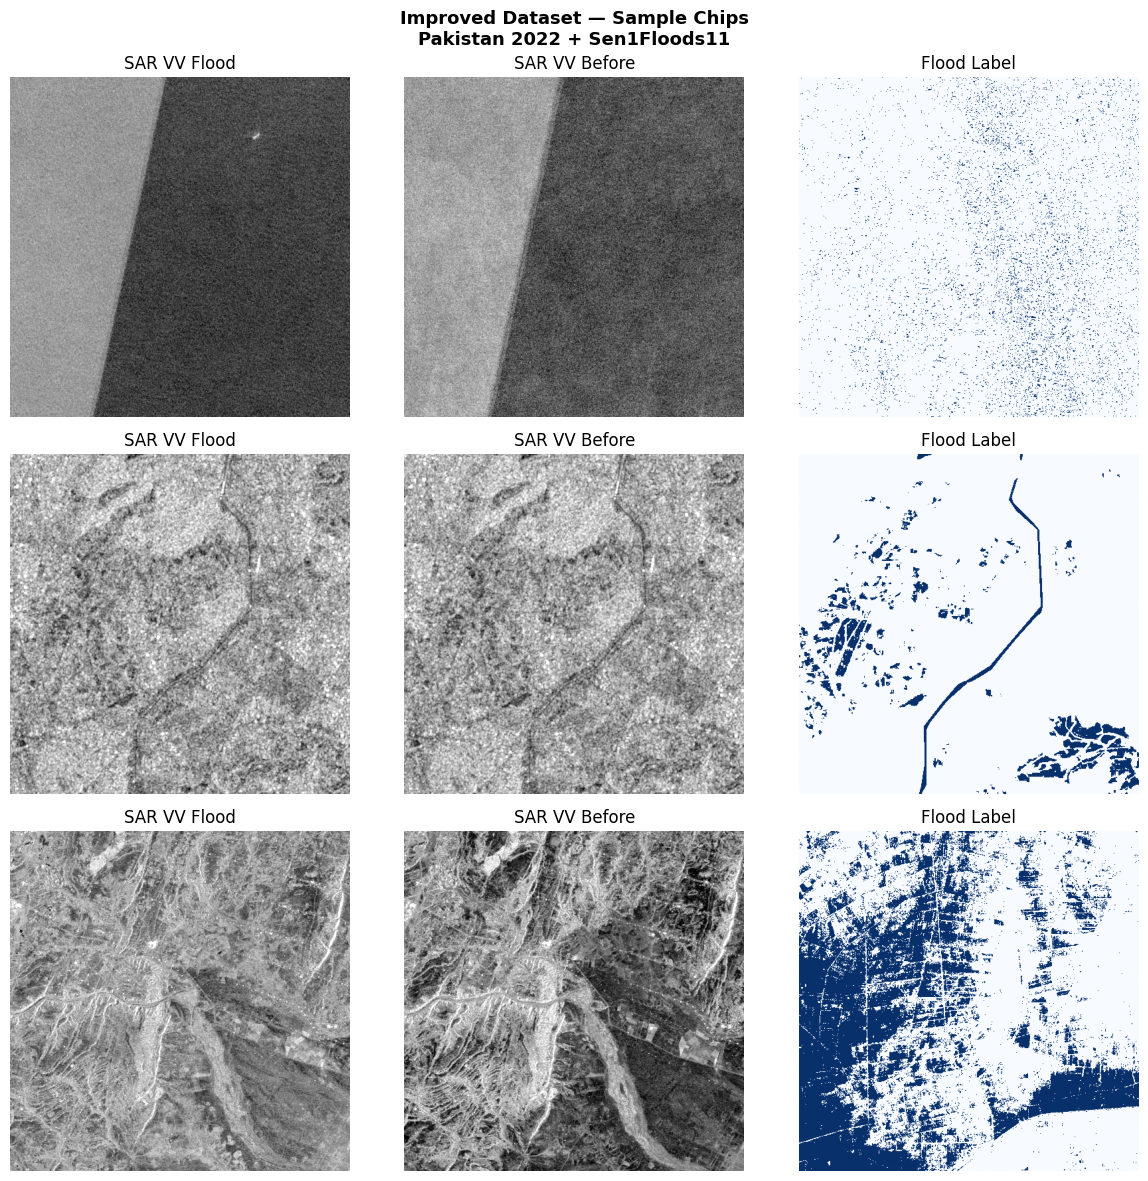


✓ Dataset verified and ready for retraining!

Now open notebook 06 and make the 4 changes
then retrain FloodPINN!


In [ ]:
# ============================================================
# Cell 9 (Fixed) — Verify and visualise
# ============================================================

import h5py
import numpy as np
import matplotlib.pyplot as plt
import random
import os

CHIPS_OUT = (
    '/content/drive/MyDrive/FloodPINN_ImprovedChips')

print("Improved Dataset Summary:")
print("=" * 45)

total_chips = 0
for split in ['train', 'val', 'test']:
    path = f'{CHIPS_OUT}/improved_{split}.h5'
    if os.path.exists(path):
        with h5py.File(path, 'r') as hf:
            n        = len(hf['X'])
            y_sample = hf['y'][:100]
            flood_pct = (y_sample==1).mean()*100
        size_gb = os.path.getsize(path)/1e9
        print(f"  {split:6s} : {n:5d} chips — "
              f"flood {flood_pct:.1f}% — "
              f"{size_gb:.2f} GB")
        total_chips += n

print(f"\n  TOTAL : {total_chips} chips")

# Visualise — sort indices for HDF5
with h5py.File(
        f'{CHIPS_OUT}/improved_train.h5', 'r') as hf:
    n = len(hf['X'])
    # HDF5 requires SORTED indices
    idx = sorted(random.sample(range(n), 3))
    X_s = hf['X'][idx]
    y_s = hf['y'][idx]

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
fig.suptitle(
    'Improved Dataset — Sample Chips\n'
    'Pakistan 2022 + Sen1Floods11',
    fontsize=13, fontweight='bold')

for row in range(3):
    axes[row,0].imshow(
        X_s[row,2], cmap='gray')
    axes[row,0].set_title('SAR VV Flood')
    axes[row,0].axis('off')

    axes[row,1].imshow(
        X_s[row,0], cmap='gray')
    axes[row,1].set_title('SAR VV Before')
    axes[row,1].axis('off')

    axes[row,2].imshow(
        y_s[row], cmap='Blues',
        vmin=0, vmax=1)
    axes[row,2].set_title('Flood Label')
    axes[row,2].axis('off')

plt.tight_layout()
plt.savefig(
    f'{CHIPS_OUT}/improved_sample.png',
    dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ Dataset verified and ready for retraining!")
print("\nNow open notebook 06 and make the 4 changes")
print("then retrain FloodPINN!")

In [ ]:
# ============================================================
# Cell 10 — Retrain FloodPINN with improved data
# ============================================================

CHIPS_OUT = (
    '/content/drive/MyDrive/FloodPINN_ImprovedChips')

print("=" * 55)
print("  Ready to Retrain!")
print("=" * 55)
print(f"""
Open notebook 06_physics_uncertainty.ipynb
and make these 4 changes:

CHANGE 1 — Data folder (Cell 1):
  OLD: DATA_FOLDER = f'{{DRIVE_BASE}}/FloodPINN_Chips'
  NEW: DATA_FOLDER = '{CHIPS_OUT}'

CHANGE 2 — HDF5 filenames (Cell 2):
  OLD: f'{{DATA_FOLDER}}/floodpinn_train.h5'
  NEW: f'{{DATA_FOLDER}}/improved_train.h5'

  OLD: f'{{DATA_FOLDER}}/floodpinn_val.h5'
  NEW: f'{{DATA_FOLDER}}/improved_val.h5'

  OLD: f'{{DATA_FOLDER}}/floodpinn_test.h5'
  NEW: f'{{DATA_FOLDER}}/improved_test.h5'

CHANGE 3 — Stronger encoder (Cell 3):
  OLD: encoder='efficientnet-b0'
  NEW: encoder='resnet34'

CHANGE 4 — More epochs (Cell 1):
  OLD: 'epochs': 30
  NEW: 'epochs': 50

Then run all cells.

EXPECTED RESULTS:
  Current F1  : 0.2788
  Target F1   : 0.50-0.65
  Reason      : 310 clean hand-labels +
                2801 chips = larger dataset
                + ResNet34 stronger encoder
                + 50 epochs full convergence
""")

print("Save notebook 08 to GitHub:")
print("  File → Save a copy in GitHub")
print("  Path: notebooks/08_improved_labels.ipynb")
print("  Commit: Add Sen1Floods11 + improved labels")

  Ready to Retrain!

Open notebook 06_physics_uncertainty.ipynb
and make these 4 changes:

CHANGE 1 — Data folder (Cell 1):
  OLD: DATA_FOLDER = f'{DRIVE_BASE}/FloodPINN_Chips'
  NEW: DATA_FOLDER = '/content/drive/MyDrive/FloodPINN_ImprovedChips'

CHANGE 2 — HDF5 filenames (Cell 2):
  OLD: f'{DATA_FOLDER}/floodpinn_train.h5'
  NEW: f'{DATA_FOLDER}/improved_train.h5'

  OLD: f'{DATA_FOLDER}/floodpinn_val.h5'
  NEW: f'{DATA_FOLDER}/improved_val.h5'

  OLD: f'{DATA_FOLDER}/floodpinn_test.h5'
  NEW: f'{DATA_FOLDER}/improved_test.h5'

CHANGE 3 — Stronger encoder (Cell 3):
  OLD: encoder='efficientnet-b0'
  NEW: encoder='resnet34'

CHANGE 4 — More epochs (Cell 1):
  OLD: 'epochs': 30
  NEW: 'epochs': 50

Then run all cells.

EXPECTED RESULTS:
  Current F1  : 0.2788
  Target F1   : 0.50-0.65
  Reason      : 310 clean hand-labels +
                2801 chips = larger dataset
                + ResNet34 stronger encoder
                + 50 epochs full convergence

Save notebook 08 to GitHub:
  